# Toronto Auto Theft Analysis

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

# Import your helper module
import sys
sys.path.insert(0, '..')
from src.helpers import *

In [15]:
# Load all the columns
pd.set_option('display.max_columns', None)

df = pd.read_csv("../data/dataset.csv")

## 1. Introduction  

This dataset comes from the Toronto Police Service Open Data portal and contains records of every reported auto theft in Toronto from 2014 to 2025.             
I chose it because it offered a long enough time horizon to distinguish a genuine trend from a temporary spike, and because auto theft patterns have direct implications for public safety policy across the province.          
I was curious whether the problem had gotten worse over time, which neighbourhoods were most affected, and whether the premise types being targeted had shifted alongside the overall trend.

In [16]:
df

,OBJECTID,EVENT_UNIQUE_ID,REPORT_DATE,OCC_DATE,REPORT_YEAR,REPORT_MONTH,REPORT_DAY,REPORT_DOY,REPORT_DOW,REPORT_HOUR,OCC_YEAR,OCC_MONTH,OCC_DAY,OCC_DOY,OCC_DOW,OCC_HOUR,DIVISION,LOCATION_TYPE,PREMISES_TYPE,UCR_CODE,UCR_EXT,OFFENCE,CSI_CATEGORY,HOOD_158,NEIGHBOURHOOD_158,HOOD_140,NEIGHBOURHOOD_140,LONG_WGS84,LAT_WGS84,x,y
0,1,GO-20141262837,1/1/2014 5:00:00 AM,12/25/2013 5:00:00 AM,2014,January,1,1,Wednesday,15,2013.0,December,25.0,359.0,Wednesday,0,D22,"Parking Lots (Apt., Commercial Or Non-Commercial)",Outside,2135,210,Theft Of Motor Vehicle,Auto Theft,159,Etobicoke City Centre (159),014,Islington-City Centre West (14),-79.529692,43.618988,-8.853205e+06,5.406668e+06
1,2,GO-20141263217,1/1/2014 5:00:00 AM,12/31/2013 5:00:00 AM,2014,January,1,1,Wednesday,16,2013.0,December,31.0,365.0,Tuesday,17,D33,"Apartment (Rooming House, Condo)",Apartment,2135,210,Theft Of Motor Vehicle,Auto Theft,043,Victoria Village (43),043,Victoria Village (43),-79.306754,43.734654,-8.828387e+06,5.424471e+06
2,3,GO-20141262914,1/1/2014 5:00:00 AM,1/1/2014 5:00:00 AM,2014,January,1,1,Wednesday,15,2014.0,January,1.0,1.0,Wednesday,15,D43,"Streets, Roads, Highways (Bicycle Path, Privat...",Outside,2135,210,Theft Of Motor Vehicle,Auto Theft,123,Cliffcrest (123),123,Cliffcrest (123),-79.236119,43.721827,-8.820524e+06,5.422495e+06
3,4,GO-20141266240,1/2/2014 5:00:00 AM,1/2/2014 5:00:00 AM,2014,January,2,2,Thursday,9,2014.0,January,2.0,2.0,Thursday,9,D54,"Streets, Roads, Highways (Bicycle Path, Privat...",Outside,2135,210,Theft Of Motor Vehicle,Auto Theft,060,Woodbine-Lumsden (60),060,Woodbine-Lumsden (60),-79.313796,43.688101,-8.829171e+06,5.417301e+06
4,5,GO-20141266097,1/2/2014 5:00:00 AM,1/2/2014 5:00:00 AM,2014,January,2,2,Thursday,8,2014.0,January,2.0,2.0,Thursday,1,D42,"Single Home, House (Attach Garage, Cottage, Mo...",House,2135,210,Theft Of Motor Vehicle,Auto Theft,129,Agincourt North (129),129,Agincourt North (129),-79.273925,43.813557,-8.824733e+06,5.436635e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76744,76745,GO-20252727834,12/31/2025 5:00:00 AM,12/31/2025 5:00:00 AM,2025,December,31,365,Wednesday,18,2025.0,December,31.0,365.0,Wednesday,15,D55,"Streets, Roads, Highways (Bicycle Path, Privat...",Outside,2135,210,Theft Of Motor Vehicle,Auto Theft,058,Old East York (58),058,Old East York (58),-79.330293,43.696815,-8.831008e+06,5.418643e+06
76745,76746,GO-20252727771,12/31/2025 5:00:00 AM,12/29/2025 5:00:00 AM,2025,December,31,365,Wednesday,18,2025.0,December,29.0,363.0,Monday,0,D12,"Parking Lots (Apt., Commercial Or Non-Commercial)",Outside,2135,210,Theft Of Motor Vehicle,Auto Theft,028,Rustic (28),028,Rustic (28),-79.497691,43.704136,-8.849642e+06,5.419770e+06
76746,76747,GO-20252727419,12/31/2025 5:00:00 AM,12/31/2025 5:00:00 AM,2025,December,31,365,Wednesday,18,2025.0,December,31.0,365.0,Wednesday,17,D55,"Streets, Roads, Highways (Bicycle Path, Privat...",Outside,2135,210,Theft Of Motor Vehicle,Auto Theft,057,Broadview North (57),057,Broadview North (57),-79.348106,43.687515,-8.832991e+06,5.417211e+06
76747,76748,GO-20252724940,12/31/2025 5:00:00 AM,12/31/2025 5:00:00 AM,2025,December,31,365,Wednesday,11,2025.0,December,31.0,365.0,Wednesday,10,D23,"Gas Station (Self, Full, Attached Convenience)",Commercial,2135,210,Theft Of Motor Vehicle,Auto Theft,008,Humber Heights-Westmount (8),008,Humber Heights-Westmount (8),-79.520581,43.695818,-8.852191e+06,5.418489e+06


## 2. Data Overview

In [17]:
df.head(15)

,OBJECTID,EVENT_UNIQUE_ID,REPORT_DATE,OCC_DATE,REPORT_YEAR,REPORT_MONTH,REPORT_DAY,REPORT_DOY,REPORT_DOW,REPORT_HOUR,OCC_YEAR,OCC_MONTH,OCC_DAY,OCC_DOY,OCC_DOW,OCC_HOUR,DIVISION,LOCATION_TYPE,PREMISES_TYPE,UCR_CODE,UCR_EXT,OFFENCE,CSI_CATEGORY,HOOD_158,NEIGHBOURHOOD_158,HOOD_140,NEIGHBOURHOOD_140,LONG_WGS84,LAT_WGS84,x,y
0,1,GO-20141262837,1/1/2014 5:00:00 AM,12/25/2013 5:00:00 AM,2014,January,1,1,Wednesday,15,2013.0,December,25.0,359.0,Wednesday,0,D22,"Parking Lots (Apt., Commercial Or Non-Commercial)",Outside,2135,210,Theft Of Motor Vehicle,Auto Theft,159,Etobicoke City Centre (159),014,Islington-City Centre West (14),-79.529692,43.618988,-8.853205e+06,5.406668e+06
1,2,GO-20141263217,1/1/2014 5:00:00 AM,12/31/2013 5:00:00 AM,2014,January,1,1,Wednesday,16,2013.0,December,31.0,365.0,Tuesday,17,D33,"Apartment (Rooming House, Condo)",Apartment,2135,210,Theft Of Motor Vehicle,Auto Theft,043,Victoria Village (43),043,Victoria Village (43),-79.306754,43.734654,-8.828387e+06,5.424471e+06
2,3,GO-20141262914,1/1/2014 5:00:00 AM,1/1/2014 5:00:00 AM,2014,January,1,1,Wednesday,15,2014.0,January,1.0,1.0,Wednesday,15,D43,"Streets, Roads, Highways (Bicycle Path, Privat...",Outside,2135,210,Theft Of Motor Vehicle,Auto Theft,123,Cliffcrest (123),123,Cliffcrest (123),-79.236119,43.721827,-8.820524e+06,5.422495e+06
3,4,GO-20141266240,1/2/2014 5:00:00 AM,1/2/2014 5:00:00 AM,2014,January,2,2,Thursday,9,2014.0,January,2.0,2.0,Thursday,9,D54,"Streets, Roads, Highways (Bicycle Path, Privat...",Outside,2135,210,Theft Of Motor Vehicle,Auto Theft,060,Woodbine-Lumsden (60),060,Woodbine-Lumsden (60),-79.313796,43.688101,-8.829171e+06,5.417301e+06
4,5,GO-20141266097,1/2/2014 5:00:00 AM,1/2/2014 5:00:00 AM,2014,January,2,2,Thursday,8,2014.0,January,2.0,2.0,Thursday,1,D42,"Single Home, House (Attach Garage, Cottage, Mo...",House,2135,210,Theft Of Motor Vehicle,Auto Theft,129,Agincourt North (129),129,Agincourt North (129),-79.273925,43.813557,-8.824733e+06,5.436635e+06
5,6,GO-20141265947,1/2/2014 5:00:00 AM,1/1/2014 5:00:00 AM,2014,January,2,2,Thursday,8,2014.0,January,1.0,1.0,Wednesday,15,D23,"Parking Lots (Apt., Commercial Or Non-Commercial)",Outside,2135,210,Theft Of Motor Vehicle,Auto Theft,002,Mount Olive-Silverstone-Jamestown (2),002,Mount Olive-Silverstone-Jamestown (2),-79.595344,43.744299,-8.860513e+06,5.425957e+06
6,7,GO-20141265795,1/2/2014 5:00:00 AM,1/1/2014 5:00:00 AM,2014,January,2,2,Thursday,7,2014.0,January,1.0,1.0,Wednesday,19,D23,"Parking Lots (Apt., Commercial Or Non-Commercial)",Outside,2135,210,Theft Of Motor Vehicle,Auto Theft,009,Edenbridge-Humber Valley (9),009,Edenbridge-Humber Valley (9),-79.512451,43.685520,-8.851286e+06,5.416904e+06
7,8,GO-20141272160,1/3/2014 5:00:00 AM,1/2/2014 5:00:00 AM,2014,January,3,3,Friday,7,2014.0,January,2.0,2.0,Thursday,18,D54,"Apartment (Rooming House, Condo)",Apartment,2135,210,Theft Of Motor Vehicle,Auto Theft,054,O'Connor-Parkview (54),054,O'Connor-Parkview (54),-79.297069,43.698249,-8.827309e+06,5.418864e+06
8,9,GO-20141273126,1/3/2014 5:00:00 AM,1/2/2014 5:00:00 AM,2014,January,3,3,Friday,11,2014.0,January,2.0,2.0,Thursday,20,D31,"Streets, Roads, Highways (Bicycle Path, Privat...",Outside,2135,210,Theft Of Motor Vehicle,Auto Theft,025,Glenfield-Jane Heights (25),025,Glenfield-Jane Heights (25),-79.513653,43.741235,-8.851419e+06,5.425485e+06
9,10,GO-20141275619,1/3/2014 5:00:00 AM,12/20/2013 5:00:00 AM,2014,January,3,3,Friday,17,2013.0,December,20.0,354.0,Friday,3,D43,"Single Home, House (Attach Garage, Cottage, Mo...",House,2135,210,Theft Of Motor Vehicle,Auto Theft,157,Bendale South (157),127,Bendale (127),-79.248540,43.748432,-8.821907e+06,5.426594e+06


In [18]:
df.tail(15)

,OBJECTID,EVENT_UNIQUE_ID,REPORT_DATE,OCC_DATE,REPORT_YEAR,REPORT_MONTH,REPORT_DAY,REPORT_DOY,REPORT_DOW,REPORT_HOUR,OCC_YEAR,OCC_MONTH,OCC_DAY,OCC_DOY,OCC_DOW,OCC_HOUR,DIVISION,LOCATION_TYPE,PREMISES_TYPE,UCR_CODE,UCR_EXT,OFFENCE,CSI_CATEGORY,HOOD_158,NEIGHBOURHOOD_158,HOOD_140,NEIGHBOURHOOD_140,LONG_WGS84,LAT_WGS84,x,y
76734,76735,GO-20252724757,12/31/2025 5:00:00 AM,12/30/2025 5:00:00 AM,2025,December,31,365,Wednesday,11,2025.0,December,30.0,364.0,Tuesday,19,D42,"Single Home, House (Attach Garage, Cottage, Mo...",House,2135,210,Theft Of Motor Vehicle,Auto Theft,129,Agincourt North (129),129,Agincourt North (129),-79.279742,43.811052,-8.825380e+06,5.436248e+06
76735,76736,GO-20252726016,12/31/2025 5:00:00 AM,12/30/2025 5:00:00 AM,2025,December,31,365,Wednesday,14,2025.0,December,30.0,364.0,Tuesday,16,D53,"Streets, Roads, Highways (Bicycle Path, Privat...",Outside,2135,210,Theft Of Motor Vehicle,Auto Theft,056,Leaside-Bennington (56),056,Leaside-Bennington (56),-79.365594,43.701569,-8.834937e+06,5.419375e+06
76736,76737,GO-20252726016,12/31/2025 5:00:00 AM,12/30/2025 5:00:00 AM,2025,December,31,365,Wednesday,14,2025.0,December,30.0,364.0,Tuesday,16,D53,"Streets, Roads, Highways (Bicycle Path, Privat...",Outside,2135,210,Theft Of Motor Vehicle,Auto Theft,056,Leaside-Bennington (56),056,Leaside-Bennington (56),-79.365594,43.701569,-8.834937e+06,5.419375e+06
76737,76738,GO-20252726206,12/31/2025 5:00:00 AM,12/31/2025 5:00:00 AM,2025,December,31,365,Wednesday,14,2025.0,December,31.0,365.0,Wednesday,4,D43,"Single Home, House (Attach Garage, Cottage, Mo...",House,2135,210,Theft Of Motor Vehicle,Auto Theft,136,West Hill (136),136,West Hill (136),-79.167220,43.772686,-8.812855e+06,5.430332e+06
76738,76739,GO-20252726206,12/31/2025 5:00:00 AM,12/31/2025 5:00:00 AM,2025,December,31,365,Wednesday,14,2025.0,December,31.0,365.0,Wednesday,4,D43,"Single Home, House (Attach Garage, Cottage, Mo...",House,2135,210,Theft Of Motor Vehicle,Auto Theft,136,West Hill (136),136,West Hill (136),-79.167220,43.772686,-8.812855e+06,5.430332e+06
76739,76740,GO-20252726719,12/31/2025 5:00:00 AM,12/30/2025 5:00:00 AM,2025,December,31,365,Wednesday,15,2025.0,December,30.0,364.0,Tuesday,18,D43,"Streets, Roads, Highways (Bicycle Path, Privat...",Outside,2135,210,Theft Of Motor Vehicle,Auto Theft,139,Scarborough Village (139),139,Scarborough Village (139),-79.215306,43.740055,-8.818208e+06,5.425303e+06
76740,76741,GO-20252726043,12/31/2025 5:00:00 AM,12/30/2025 5:00:00 AM,2025,December,31,365,Wednesday,16,2025.0,December,30.0,364.0,Tuesday,2,D33,Unknown,Other,2135,210,Theft Of Motor Vehicle,Auto Theft,047,Don Valley Village (47),047,Don Valley Village (47),-79.347347,43.782446,-8.832906e+06,5.431837e+06
76741,76742,GO-20252726617,12/31/2025 5:00:00 AM,12/30/2025 5:00:00 AM,2025,December,31,365,Wednesday,16,2025.0,December,30.0,364.0,Tuesday,20,D22,"Parking Lots (Apt., Commercial Or Non-Commercial)",Outside,2135,210,Theft Of Motor Vehicle,Auto Theft,158,Islington (158),014,Islington-City Centre West (14),-79.563220,43.652648,-8.856937e+06,5.411845e+06
76742,76743,GO-20252727346,12/31/2025 5:00:00 AM,12/23/2025 5:00:00 AM,2025,December,31,365,Wednesday,17,2025.0,December,23.0,357.0,Tuesday,9,D42,"Single Home, House (Attach Garage, Cottage, Mo...",House,2135,210,Theft Of Motor Vehicle,Auto Theft,118,Tam O'Shanter-Sullivan (118),118,Tam O'Shanter-Sullivan (118),-79.318521,43.772789,-8.829697e+06,5.430348e+06
76743,76744,GO-20252727444,12/31/2025 5:00:00 AM,12/29/2025 5:00:00 AM,2025,December,31,365,Wednesday,18,2025.0,December,29.0,363.0,Monday,19,D32,"Single Home, House (Attach Garage, Cottage, Mo...",House,2135,210,Theft Of Motor Vehicle,Auto Theft,036,Newtonbrook West (36),036,Newtonbrook West (36),-79.432615,43.787033,-8.842398e+06,5.432544e+06


In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 76749 entries, 0 to 76748
Data columns (total 31 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   OBJECTID           76749 non-null  int64  
 1   EVENT_UNIQUE_ID    76749 non-null  str    
 2   REPORT_DATE        76749 non-null  str    
 3   OCC_DATE           76749 non-null  str    
 4   REPORT_YEAR        76749 non-null  int64  
 5   REPORT_MONTH       76749 non-null  str    
 6   REPORT_DAY         76749 non-null  int64  
 7   REPORT_DOY         76749 non-null  int64  
 8   REPORT_DOW         76749 non-null  str    
 9   REPORT_HOUR        76749 non-null  int64  
 10  OCC_YEAR           76743 non-null  float64
 11  OCC_MONTH          76743 non-null  str    
 12  OCC_DAY            76743 non-null  float64
 13  OCC_DOY            76743 non-null  float64
 14  OCC_DOW            76743 non-null  str    
 15  OCC_HOUR           76749 non-null  int64  
 16  DIVISION           76749 non-null

In [20]:
df.shape

(76749, 31)

### Observations
1. Looking at `REPORT_DATE` and `OCC_DATE` columns, every value shows a time of `5:00:00 AM`. Since the dataset already has dedicated columns for year, month, day, and hour, these 2 columns are redundant and will be **dropped** during cleaning.      
2. Looking at `df.info()`, most columns have no missing values. The only exceptions are columns `OCC_YEAR`, `OCC_MONTH`,`OCC_DAY`, `OCC_DOY` and `OCC_DOW` with only 6 missing values that will be addressed during cleaning.     
3. Based on `df.info()` out of the 31 columns, 7 are floats, 8 are integers, and 16 are objects, giving us a total of 15 numerical and 16 categorical columns.          
4. According to `df.describe()`, the median `OCC_YEAR` is 2022. That means half of all recorded auto theft occurred in the more recent years of the dataset despite the data spanning from 2014 to 2025. This hints that auto theft has been on the rise in Toronto in recent years.                
5. The mean `OCC_HOUR` is approximately 13.79. That means on average, auto thefts occur around 1-2 PM.      
6. I noticed that the `OFFENCE`, `CSI_CATEGORY`, `UCR_CODE` and `UCR_EXT` columns are consistent across the records.       
7. The `HOOD_140` and `HOOD_158` columns appear to be numeric identifiers for neighbourhoods, with the actual neighbourhood names already present in the `NEIGHBOURHOOD_140` and `NEIGHBOURHOOD_158` columns, making them redundant.

### Analytical Questions
1. Looking at yearly auto theft counts in Toronto from 2014 to 2025, does the trend show a gradual increase over time or a sudden sharp acceleration between specific years that would suggest a structural shift in how thefts were being carried out?               
2. Given the sharp rise in auto thefts between 2021 and 2023, which of Toronto's 158 neighbourhoods was hit the hardest during those peak years, and how far ahead was it compared to the rest of the city?         
3. Within West Humber-Clairville, the most heavily affected neighbourhood during Toronto's auto theft surge, how did the distribution of premises types targeted during the peak years of 2021-2023 compare to post peak?         

## 3. Data Cleaning

In [21]:
clean_df = clean_dataset(df)

### Explanation
All rows with missing values (6 in total) were removed to ensure the analysis is working with full records.   
`OBJECTID` and `EVENT_UNIQUE_ID` columns are identifiers that serve no purpose to the analysis, therefore they are removed.     
`LONG_WGS84`, `LAT_WGS84`, `x`, `y` columns are all estimated coordinates that will not be used in the analysis, therefore they are removed.
`REPORT_DATE` and `OCC_DATE` columns are already broken down into individual fields, therefore they are removed.      
`UCR_CODE`, `UCR_EXT`, `OFFENCE`, and `CSI_CATEGORY` columns each contain only 1 unique value across all 76,686 rows, therefore they are removed.       
`REPORT_YEAR`, `REPORT_MONTH`, `REPORT_DAY`, `REPORT_DOY`, `REPORT_DOW`, and `REPORT_HOUR` columns are all removed since this analysis focuses on when thefts actually happened, not when they were reported to the police. The `OCC_` columns are kept for this reason. 
The `LOCATION_TYPE` column contained lengthy values with additional context in parentheses. Everything inside and including the parentheses was removed, keeping only the main location type for cleaner grouping and visualization.
`OCC_YEAR`, `OCC_DAY`, and `OCC_DOY` columns were stored as floats and converted to integers since they represent whole numbers.            
Records before 2014 in column `OCC_YEAR` were removed. There were only 57 records spread across years 2000–2013, which is not enough data to be meaningful or representative.  

## 4. Analysis

### 1. Looking at yearly auto theft counts in Toronto from 2014 to 2025, does the trend show a gradual increase over time or a sudden sharp acceleration between specific years that would suggest a structural shift in how thefts were being carried out?  

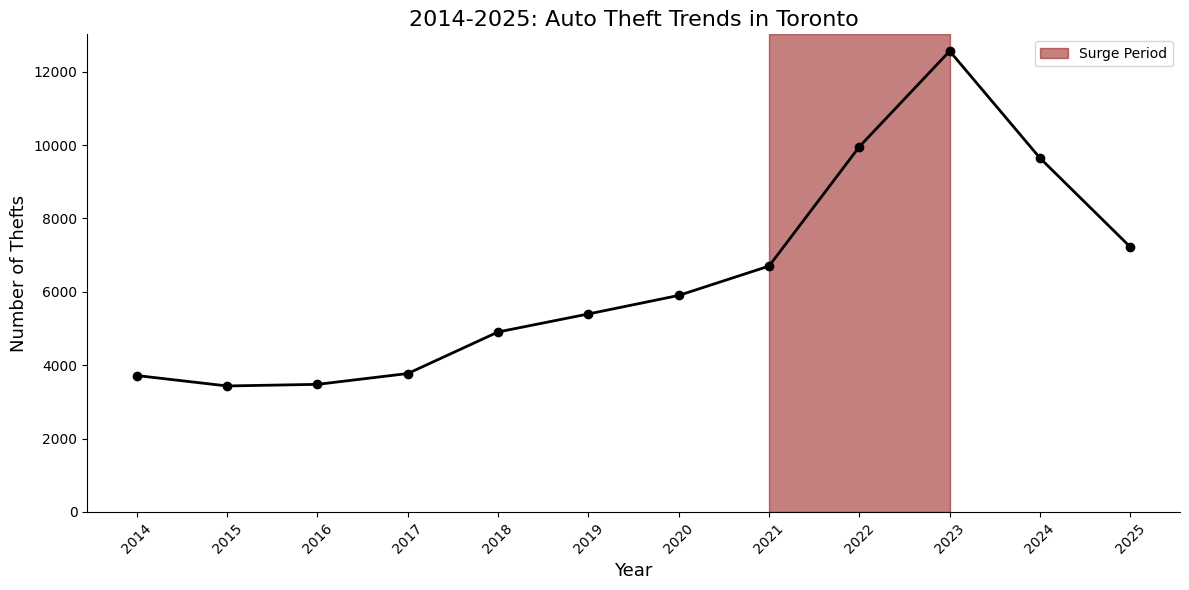

In [22]:
yearly_trends_chart(clean_df)

Toronto's auto theft numbers were mostly flat in the mid 2010s, sitting around 3,500 incidents per year. From 2017 to 2021 there was a gradual upward trend, with thefts rising steadily to nearly 6,700 by the end of that period. Between 2021 and 2023 the increase became much sharper, peaking at over 12,000 thefts in 2023. In 2024 and 2025, thefts began to decline, dropping to around 9,600 and 7,300 respectively.

The trend does not show a gradual increase over time. The sharp acceleration between 2021 and 2023 suggests a structural shift in how thefts were being carried out, likely tied to the growing vulnerability of keyless entry equipped vehicles and relay attack methods exploiting wireless key fob signals. The decline in 2024 and 2025 may reflect new Ontario legislation requiring GPS trackers on high risk vehicles, though this dataset alone cannot confirm that.

### 2. Given the sharp rise in auto thefts between 2021 and 2023, which of Toronto's 158 neighbourhoods was hit the hardest during those peak years, and how far ahead was it compared to the rest of the city?

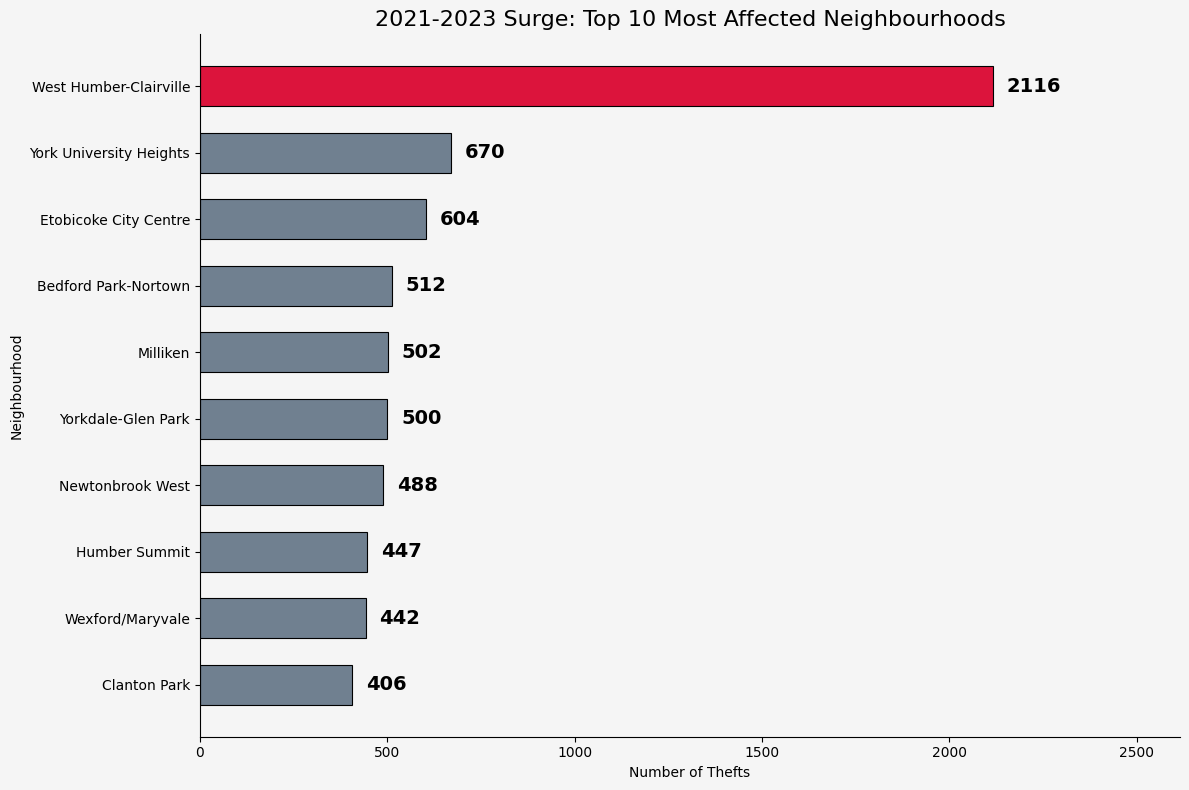

In [23]:
top10_neighbourhoods_chart(clean_df)

West Humber-Clairville recorded 2,116 thefts between 2021 and 2023, more than three times higher than any other neighbourhood in the city. York University Heights and Etobicoke City Centre followed at 670 and 604. The remaining top 10 neighbourhoods tightly clustered between 406 and 512 thefts, none coming close to the scale of West Humber-Clairville.

West Humber-Clairville's disproportionate theft numbers may be explained by a few factors. The neighbourhood sits adjacent to Pearson International Airport and has easy access to major highways like the 427 and 407, making it easier to move stolen vehicles quickly. It also has a high concentration of industrial lots, commercial parking, and large surface parking areas that provide opportunities for theft to go unnoticed.

### 3. Within West Humber-Clairville, the most heavily affected neighbourhood during Toronto's auto theft surge, how did the distribution of premises types targeted during the peak years of 2021-2023 compare to post peak?

In [24]:
premises_proportions_table(clean_df)

PREMISES_TYPE,Apartment,Commercial,House,Other,Outside,Transit
OCC_YEAR,,,,,,
2021,1.0%,17.0%,25.0%,4.0%,53.0%,0.0%
2022,1.0%,21.0%,16.0%,2.0%,60.0%,0.0%
2023,1.0%,18.0%,14.0%,3.0%,64.0%,0.0%
2024,2.0%,18.0%,15.0%,3.0%,62.0%,0.0%
2025,1.0%,20.0%,8.0%,2.0%,68.0%,2.0%


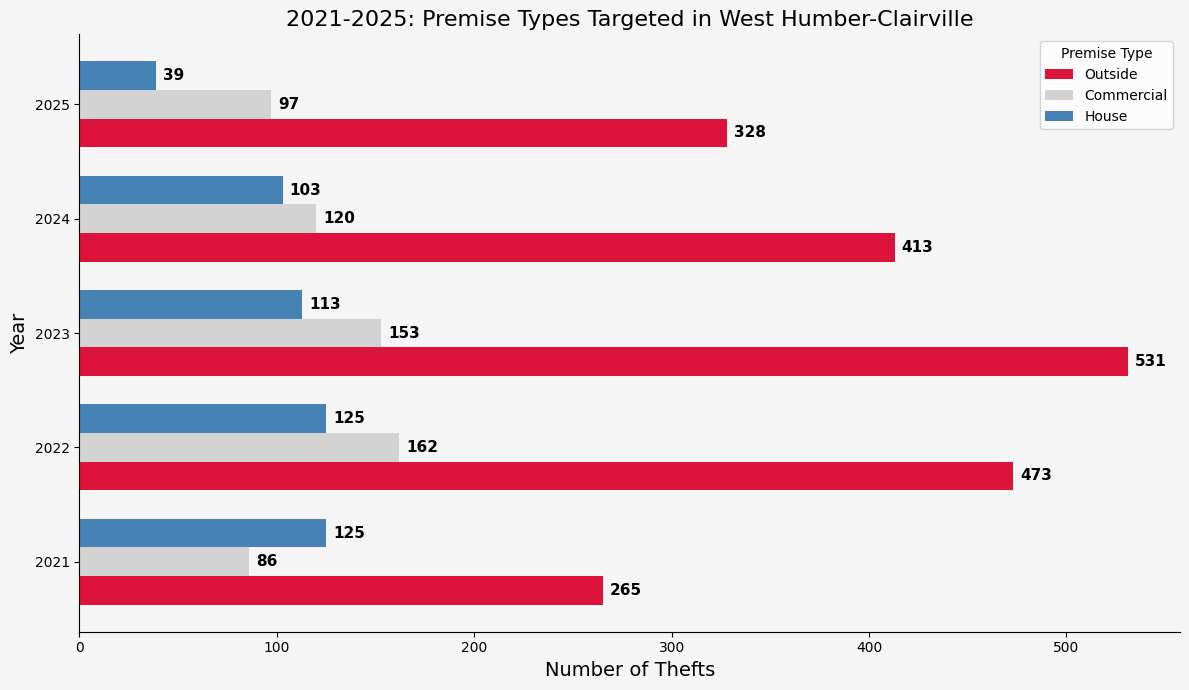

In [25]:
premises_by_years_chart(clean_df)

Outside was the dominant premise type in West Humber-Clairville every year from 2021 to 2025, consistently accounting for more than half of all thefts in the neighbourhood and growing as a share even as the surge intensified.       
Commercial premises were a distant second throughout, while House thefts made up a smaller but steady portion.              
Every other premise type combined remained negligible across all five years, making Outside not just the leading category but the defining one.

The fact that Outside thefts grew as a proportion of total thefts even as overall numbers declined suggests this was not a pattern that spread randomly across all premise types and something specific was driving it.             
Vehicles parked in open outdoor spaces were disproportionately targeted, which is consistent with relay attack methods where thieves amplify keyless fob signals to unlock and start vehicles without forced entry.             
This method works specifically on vehicles parked outside where the signal can be captured, rather than in enclosed garages or indoor structures.           
The neighbourhood's proximity to Pearson International Airport and its easy access to major highways may also be a contributing factor, as stolen vehicles could be moved out of the area quickly, though the data alone cannot confirm this connection.        
Even after the surge began to ease, Outside thefts maintained and grew their share of the total, suggesting the underlying method persisted even as the overall volume declined.

## 5. Prediction

Based on the yearly theft trends observed in West Humber-Clairville, I wanted to see if a simple model could predict how many thefts would occur in recent years using only the year as input.          
I used Linear Regression to predict yearly theft counts, training the model on 2014–2022 data and testing it on 2023–2025.

In [26]:
# Filtering to only West Humber and count the thefts per year
west_humber = clean_df[clean_df['NEIGHBOURHOOD_158'] == 'West Humber-Clairville']
yearly_counts = west_humber.groupby('OCC_YEAR').size().reset_index()
yearly_counts.columns = ['OCC_YEAR', 'THEFT_COUNT']

# Defining the input and the target
X = yearly_counts[['OCC_YEAR']]
y = yearly_counts['THEFT_COUNT']

# Splitting into training and test
# shuffle = False ---> years in order
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, shuffle = False)

# Creating the model and train it on the training data
model = LinearRegression().fit(X_train, y_train)

# Making predictions on the test years and for 2026
y_pred = model.predict(X_test)
prediction_2026 = model.predict(pd.DataFrame({'OCC_YEAR': [2026]}))

# Printing the results and evaluate
print("Year | Actual | Predicted")
for year, actual, predicted in zip(X_test['OCC_YEAR'], y_test, y_pred):
    print(year, "|", actual, "|", round(predicted))
print("MAE:", round(mean_absolute_error(y_test, y_pred), 1))
print("RMSE:", round(root_mean_squared_error(y_test, y_pred), 1))
print("Predicted thefts in West Humber-Clairville for 2026:", round(prediction_2026[0]))

Year | Actual | Predicted
2023 | 831 | 673
2024 | 665 | 722
2025 | 485 | 770
MAE: 166.3
RMSE: 190.7
Predicted thefts in West Humber-Clairville for 2026: 818


The model predicted 673 thefts in 2023 but the actual number was 831. It underestimated because 2023 was the peak of the surge, a sharp spike that the model could not have anticipated from the gradual upward trend it learned from earlier years.        
For 2024 and 2025 the opposite happened. The model predicted 722 and 770 while the actual numbers were 665 and 485, meaning it kept expecting growth while theft numbers were actually falling.     
The MAE of 166 and RMSE of 190 both reflect how unusual the surge years were compared to the historical pattern.        
The 2026 prediction of 818 assumes the linear trend continues, but given the sharp decline seen in 2024 and 2025 the real number will likely be much lower than that.

## 6. Conclusions  

Toronto's auto theft surge between 2021 and 2023 was not a gradual worsening but a **structural shift**, with yearly incidents climbing from around 3,500 in the mid 2010s to over 12,000 at the peak in 2023, possibly driven by relay attacks on keyless entry vehicles that spread rapidly before countermeasures began to take effect.      
West Humber-Clairville absorbed the impact more than any other neighbourhood, recording **over three times the thefts of the next hardest hit area**, and the fact that Outside premise type grew as a share of total thefts even as overall numbers declined confirms the method was specific and persistent rather than opportunistic.            
The prediction model reinforced this point, as it was trained on years of steady growth and had no way of anticipating a spike that sharp or a decline that sudden, though the data alone cannot confirm what caused either shift.      
What I would explore further is whether the post 2023 decline tracks with Ontario's GPS tracker legislation for high risk vehicles, and whether the same Outside dominant pattern holds across the other heavily affected neighbourhoods.